In [1]:
# Load + split
import pandas as pd, numpy as np, pickle, json
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import shap

df = pd.read_csv('../data/flipkart_processed.csv')

FEATURES = [
    'comp_avg_price',
    'comp_min_price',
    'comp_max_price',
    'comp_spread',
    'log_retail',
    'rating',
    'brand_encoded',
    'category_encoded',
]

TARGET = 'discounted_price'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 14,615 | Test: 3,654


In [2]:
# Train XGBoost
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric='mae',
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

preds = model.predict(X_test)
mae   = mean_absolute_error(y_test, preds)
r2    = r2_score(y_test, preds)

print(f"\n✅ MAE:  ₹{mae:,.2f}")
print(f"✅ R²:   {r2:.4f}")
print(f"✅ MAPE: {(np.abs((y_test - preds)/y_test)).mean()*100:.1f}%")

[0]	validation_0-mae:1486.23923
[50]	validation_0-mae:123.80834
[100]	validation_0-mae:22.72533
[150]	validation_0-mae:17.29394
[200]	validation_0-mae:17.03263
[250]	validation_0-mae:16.68560
[300]	validation_0-mae:16.33051
[350]	validation_0-mae:16.05154
[400]	validation_0-mae:15.92605
[450]	validation_0-mae:15.73107
[499]	validation_0-mae:15.61401

✅ MAE:  ₹15.61
✅ R²:   0.9970
✅ MAPE: 0.4%


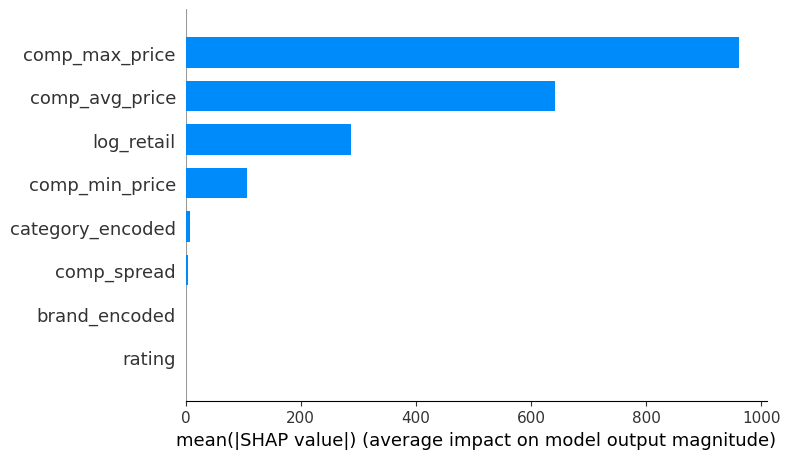

In [3]:
import shap, xgboost as xgb
import os

os.makedirs('../models', exist_ok=True)

# Round-trip through native format so SHAP gets clean float thresholds
model.get_booster().save_model('../models/_shap_booster.json')

_clean_booster = xgb.Booster()
_clean_booster.load_model('../models/_shap_booster.json')

explainer = shap.TreeExplainer(_clean_booster)
sv        = explainer.shap_values(X_test[:500])

shap.summary_plot(sv, X_test[:500], feature_names=FEATURES,
                  plot_type="bar", show=True)

In [15]:
import pickle, os, json
import xgboost as xgb

# Save native XGBoost format
os.makedirs('../models', exist_ok=True)
model.get_booster().save_model('../models/xgb_model.json')

# Normalize booster (fixed path instead of /tmp)
tmp_path = '../models/_tmp_booster.json'
model.get_booster().save_model(tmp_path)

_b = xgb.Booster()
_b.load_model(tmp_path)

model._Booster = _b
pickle.dump(model, open('../models/xgb_model.pkl', 'wb'))

meta = {
    "features": FEATURES,
    "mae":      round(float(mae), 2),
    "r2":       round(float(r2), 4),
    "n_train":  len(X_train),
    "n_test":   len(X_test),
    "target":   TARGET,
    "dataset":  "flipkart_kaggle",
}
with open('../models/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("✅ Model saved (native + pickle)")
print(f"   MAE: ₹{mae:,.2f}")

✅ Model saved (native + pickle)
   MAE: ₹15.61
